In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime

from src.data_cleaning import ASCAT_ERA5 as utils
from src.data_cleaning.general import plot, validate_time_index, validate_data_cleaning_input, filter_df
from src import constants as c

# Data Understanding and Preparation of the ASCAT and ERA5 Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for all ASCAT and ERA5 data in `data/raw/ASCAT` and `data/raw/ERA`. The cleaned data will then be exported to their respective folders in `data/cleaned`.

---

### Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
# key columns
ASCAT_short_var_name = 'backscatter40'
ERA5_short_var_name = 'stl1'
ASCAT_long_var_name = '40° Normalized Backscatter (dB)'
ERA5_long_var_name = 'Soil Temperature Level 1 (C)'

# path variables
ASCAT = 'ASCAT'
ERA5 = 'ERA5'
raw_path = Path('../data/raw/ASCAT_ERA5')
c.CLEANED_DATA_PATH.mkdir(parents=True, exist_ok=True)

### 1.2 Functions

In [3]:
def data_cleaning(data_path: Path, ismn_sites_path: Path,
                  station: str, system: str, key_variable: str,
                  date_range=None) -> pd.DataFrame:
    """
    Preprocessing of raw ASCAT or ERA5 data.
    :param data_path: path to csv file
    :param ismn_sites_path: path to csv file containing ISMN site information
    :param station: must match exactly name in ISMN_site_survey.csv
    :param system: ASCAT or ERA5, case-insensitive
    :param key_variable: name of variable of interest (in csv)
    :param date_range: a list of datetime objects. Data outside this range is filtered out. Min is inclusive and max is exclusive. Assumed that input is in the same timezone as df.index. If date_range is not valid for given df, date_range will be adjusted to be valid.
    :return: cleaned dataframe
    """
    # validate inputs
    validate_data_cleaning_input(data_path, date_range)

    # load data
    df = utils.collect_data(data_path, ismn_sites_path, station, system)
    utils.check_df_cols(df, system)

    # report NaN count and proportion
    na_count = df.isnull().sum()[key_variable]
    print(f'There are {na_count} nulls out of {len(df)} datapoints ({round(na_count/len(df),2)}% missing).')

    # data preprocessing
    df = df.dropna(subset=[key_variable]) # no data imputation/interpolation for ASCAT
    df = utils.round_nearest_hour_index(df)
    df = filter_df(df, date_range=date_range)

    # only keep required columns
    if system.upper() == 'ASCAT':
        if c.ASCAT_KEY_COLS is not None:
            df = df[c.ASCAT_KEY_COLS]
    if system.upper() == 'ERA5':
        if c.ERA5_KEY_COL is not None:
            df = df[c.ERA5_KEY_COL]

    # data imputation
    if system.upper() == 'ERA5':
        df = utils.impute_hourly(df)

    return df

def data_reporting(df: pd.DataFrame, variable: str, station_name: str, system: str, ylabel: str) -> None:
    """
    Reporting of preprocessed ASCAT and ERA5 data.
    :param df: can be output from soil_temp_data_cleaning()
    :param variable: full variable name
    :param station_name: official name of ISMN station
    :param system: name of sensor system
    :param ylabel: y-label for plot
    :return:
    """
    # check input values
    if variable not in df.columns:
        raise KeyError(f'df missing required column "{variable}".')
    # check input df index
    validate_time_index(df)

    print('Summary statistics:')
    display(df.describe())
    print('Show head of df:')
    display(df.head())

    plot(df, variable, station=station_name, system=system, form='line', y_label=ylabel)

def plot_one_year(df: pd.DataFrame, variable: str, station: str, system: str, ylabel: str) -> None:
    """
    Plot one year of df from 2010-06-01 to 2011-06-01.
    :param df: df after all preprocessing
    :param variable: short variable name
    :param station: ISMN station name
    :param system: sensor system name
    :param ylabel: full variable name for plot
    :return: None
    """
    plot_obj = plot(df, variable, station, system, 'line', ylabel,
         start=datetime(2010, 6, 1), end=datetime(2011, 6, 1))

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

#### ASCAT

There are 1618 nulls out of 17799 datapoints (0.09% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,16181.000000,16181.000000,16181.000000,16181.000000
mean,-14.759586,0.497497,0.490328,3.727458
std,1.715188,0.500009,0.499922,0.751516
min,-19.637800,0.000000,0.000000,3.000000
25%,-15.928318,0.000000,0.000000,3.000000
50%,-14.600672,0.000000,0.000000,4.000000
75%,-13.589661,1.000000,1.000000,4.000000
max,-6.488361,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 04:00:00+00:00,-18.138327,1,0,3
2007-01-02 04:00:00+00:00,-18.249712,1,0,3
2007-01-02 16:00:00+00:00,-18.546434,1,1,3
2007-01-03 17:00:00+00:00,-17.615808,0,1,3
2007-01-04 03:00:00+00:00,-15.992000,0,0,3


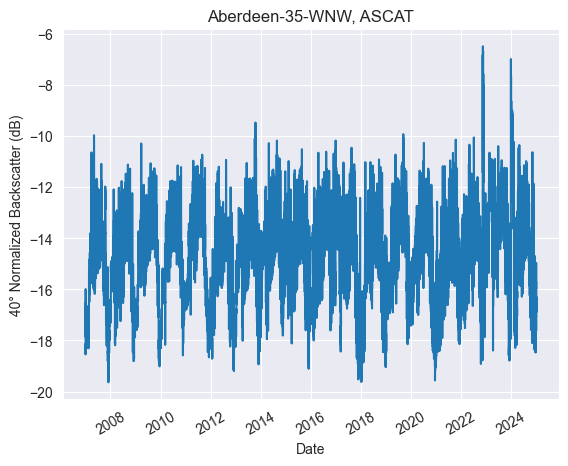

In [4]:
ASCAT_aberdeen_df = data_cleaning(data_path=raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=c.ABERDEEN_NAME,
                                  system=ASCAT,
                                  key_variable=ASCAT_short_var_name,
                                  date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_aberdeen_df,
               variable=ASCAT_short_var_name,
               station_name=c.ABERDEEN_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

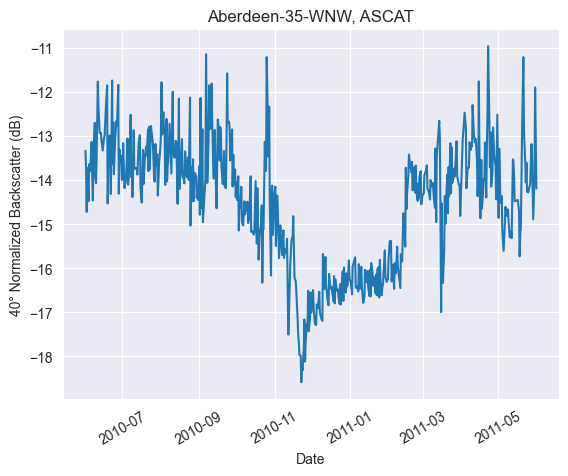

In [5]:
plot_one_year(ASCAT_aberdeen_df, ASCAT_short_var_name, c.ABERDEEN_NAME, ASCAT, ASCAT_long_var_name)

In [6]:
# export to csv
ASCAT_aberdeen_df.to_csv(c.CLEANED_DATA_PATH / f'{c.ABERDEEN_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,8.077134
std,10.985621
min,-25.262360
25%,-1.368393
50%,7.281596
75%,18.007762
max,33.542816


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-3.689606
2007-01-01 01:00:00+00:00,-4.181793
2007-01-01 02:00:00+00:00,-4.673981
2007-01-01 03:00:00+00:00,-5.166168
2007-01-01 04:00:00+00:00,-5.658356


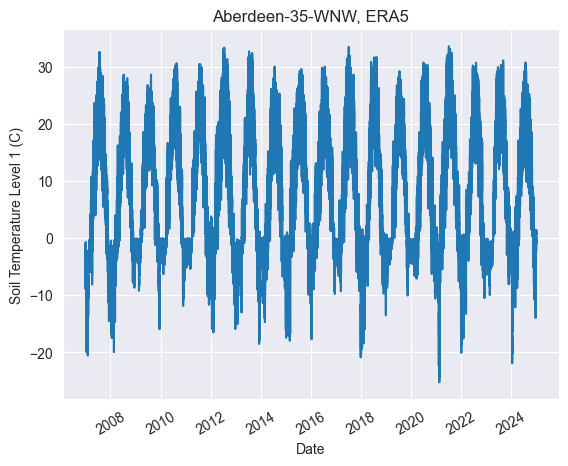

In [7]:
ERA5_aberdeen_df = data_cleaning(data_path=raw_path,
                                 ismn_sites_path=c.SITE_SURVEY_PATH,
                                 station=c.ABERDEEN_NAME,
                                 system=ERA5,
                                 key_variable=ERA5_short_var_name,
                                 date_range=c.DATE_RANGE)
data_reporting(df=ERA5_aberdeen_df,
               variable=ERA5_short_var_name,
               station_name=c.ABERDEEN_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [8]:
# export to csv
ERA5_aberdeen_df.to_csv(c.CLEANED_DATA_PATH / f'{c.ABERDEEN_NAME}_{ERA5}.csv')

### 2.2 Jamestown-38-WSW

#### ASCAT

There are 2199 nulls out of 18830 datapoints (0.12% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,16631.000000,16631.000000,16631.000000,16631.000000
mean,-14.562716,0.484878,0.495280,3.726054
std,1.587096,0.499786,0.499993,0.749018
min,-19.451506,0.000000,0.000000,3.000000
25%,-15.598405,0.000000,0.000000,3.000000
50%,-14.439528,0.000000,0.000000,4.000000
75%,-13.442534,1.000000,1.000000,4.000000
max,-6.382537,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 04:00:00+00:00,-18.511513,1,0,3
2007-01-02 04:00:00+00:00,-18.238005,1,0,3
2007-01-02 16:00:00+00:00,-18.214222,1,1,3
2007-01-03 17:00:00+00:00,-15.158000,0,1,3
2007-01-04 03:00:00+00:00,-14.611470,0,0,3


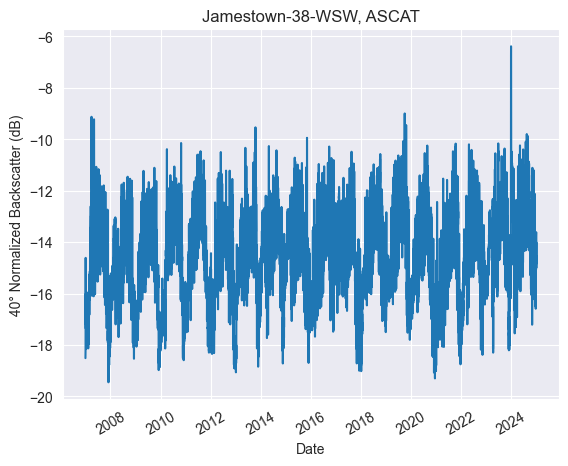

In [9]:
ASCAT_jamestown_df = data_cleaning(data_path=raw_path,
                                   ismn_sites_path=c.SITE_SURVEY_PATH,
                                   station=c.JAMESTOWN_NAME,
                                   system=ASCAT,
                                   key_variable=ASCAT_short_var_name,
                                   date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_jamestown_df,
               variable=ASCAT_short_var_name,
               station_name=c.JAMESTOWN_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

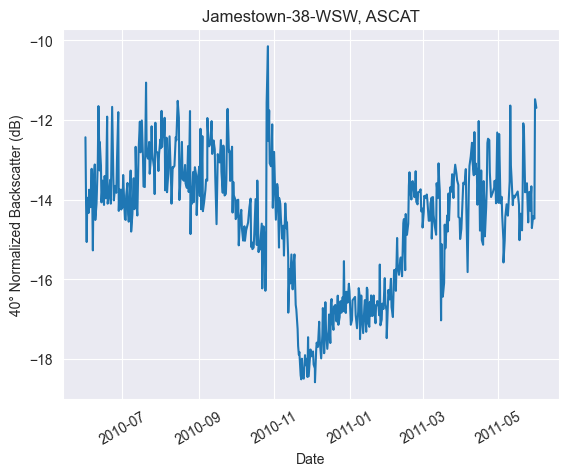

In [10]:
plot_one_year(ASCAT_jamestown_df, ASCAT_short_var_name, c.JAMESTOWN_NAME, ASCAT, ASCAT_long_var_name)

In [11]:
# export to csv
ASCAT_jamestown_df.to_csv(c.CLEANED_DATA_PATH / f'{c.JAMESTOWN_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,7.527132
std,10.847229
min,-25.742828
25%,-1.558657
50%,6.579676
75%,17.234001
max,34.929596


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-4.855621
2007-01-01 01:00:00+00:00,-5.320465
2007-01-01 02:00:00+00:00,-5.785309
2007-01-01 03:00:00+00:00,-6.250153
2007-01-01 04:00:00+00:00,-6.714996


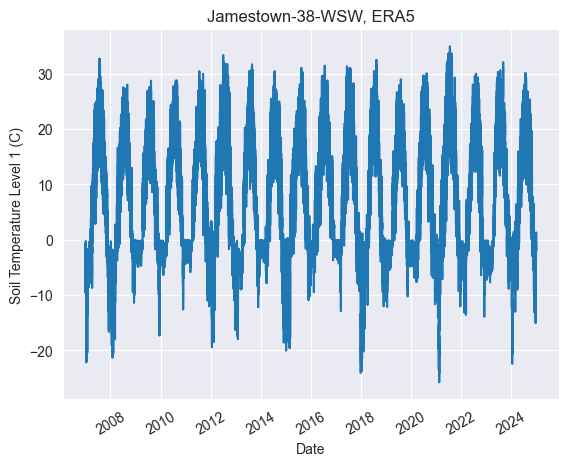

In [12]:
ERA5_jamestown_df = data_cleaning(data_path=raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=c.JAMESTOWN_NAME,
                                  system=ERA5,
                                  key_variable=ERA5_short_var_name,
                                  date_range=c.DATE_RANGE)
data_reporting(df=ERA5_jamestown_df,
               variable=ERA5_short_var_name,
               station_name=c.JAMESTOWN_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [13]:
# export to csv
ERA5_jamestown_df.to_csv(c.CLEANED_DATA_PATH / f'{c.JAMESTOWN_NAME}_{ERA5}.csv')

### 2.3 Gobblers Knob

#### ASCAT

There are 3620 nulls out of 36140 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,32520.000000,32520.000000,32520.000000,32520.000000
mean,-11.629826,0.429982,0.503475,3.716082
std,1.476238,0.495081,0.499996,0.746541
min,-15.863902,0.000000,0.000000,3.000000
25%,-12.957079,0.000000,0.000000,3.000000
50%,-11.829261,0.000000,1.000000,4.000000
75%,-10.211492,1.000000,1.000000,4.000000
max,-7.769168,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 20:00:00+00:00,-12.790222,1,1,3
2007-01-02 06:00:00+00:00,-13.280205,0,0,3
2007-01-02 07:00:00+00:00,-12.628483,1,0,3
2007-01-02 23:00:00+00:00,-12.695719,0,1,3
2007-01-03 05:00:00+00:00,-13.297269,0,0,3


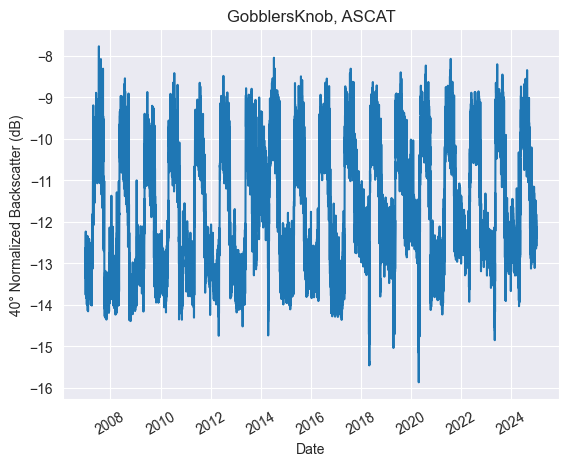

In [14]:
ASCAT_gobblers_knob_df = data_cleaning(data_path=raw_path,
                                       ismn_sites_path=c.SITE_SURVEY_PATH,
                                       station=c.GOBBLERS_KNOB_NAME,
                                       system=ASCAT,
                                       key_variable=ASCAT_short_var_name,
                                       date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_gobblers_knob_df,
               variable=ASCAT_short_var_name,
               station_name=c.GOBBLERS_KNOB_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

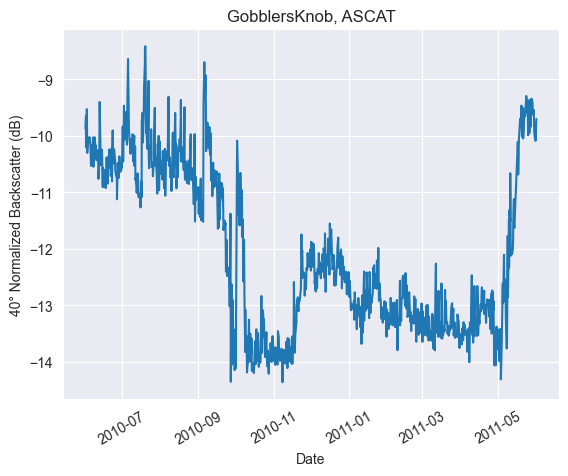

In [15]:
plot_one_year(ASCAT_gobblers_knob_df, ASCAT_short_var_name, c.GOBBLERS_KNOB_NAME, ASCAT, ASCAT_long_var_name)

In [16]:
# export to csv
ASCAT_gobblers_knob_df.to_csv(c.CLEANED_DATA_PATH / f'{c.GOBBLERS_KNOB_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,1.721938
std,7.909584
min,-32.260240
25%,-3.299525
50%,-0.866709
75%,8.661230
max,25.048218


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-1.519684
2007-01-01 01:00:00+00:00,-1.662587
2007-01-01 02:00:00+00:00,-1.805491
2007-01-01 03:00:00+00:00,-1.948395
2007-01-01 04:00:00+00:00,-2.091298


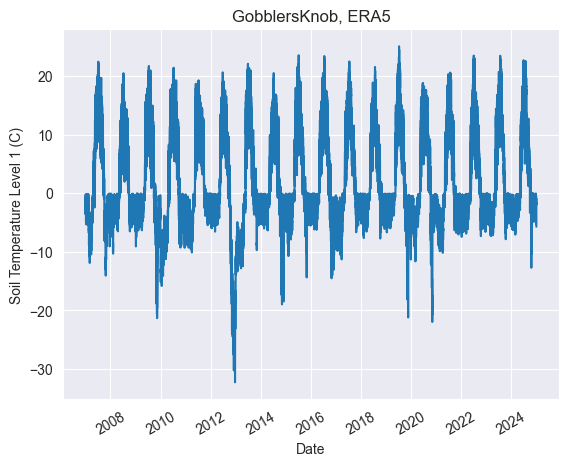

In [17]:
ERA5_gobblers_knob_df = data_cleaning(data_path=raw_path,
                                      ismn_sites_path=c.SITE_SURVEY_PATH,
                                      station=c.GOBBLERS_KNOB_NAME,
                                      system=ERA5,
                                      key_variable=ERA5_short_var_name,
                                      date_range=c.DATE_RANGE)
data_reporting(df=ERA5_gobblers_knob_df,
               variable=ERA5_short_var_name,
               station_name=c.GOBBLERS_KNOB_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [18]:
# export to csv
ERA5_gobblers_knob_df.to_csv(c.CLEANED_DATA_PATH / f'{c.GOBBLERS_KNOB_NAME}_{ERA5}.csv')

### 2.4 Nenana

#### ASCAT

There are 3433 nulls out of 32538 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,29105.000000,29105.000000,29105.000000,29105.000000
mean,-10.732013,0.443773,0.496925,3.713795
std,1.211291,0.496837,0.499999,0.746623
min,-13.780949,0.000000,0.000000,3.000000
25%,-11.801822,0.000000,0.000000,3.000000
50%,-10.593150,0.000000,0.000000,4.000000
75%,-9.633761,1.000000,1.000000,4.000000
max,-7.459589,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 20:00:00+00:00,-11.646178,1,1,3
2007-01-01 21:00:00+00:00,-12.336268,0,1,3
2007-01-02 06:00:00+00:00,-12.234253,0,0,3
2007-01-02 07:00:00+00:00,-11.359132,1,0,3
2007-01-02 19:00:00+00:00,-11.386372,1,1,3


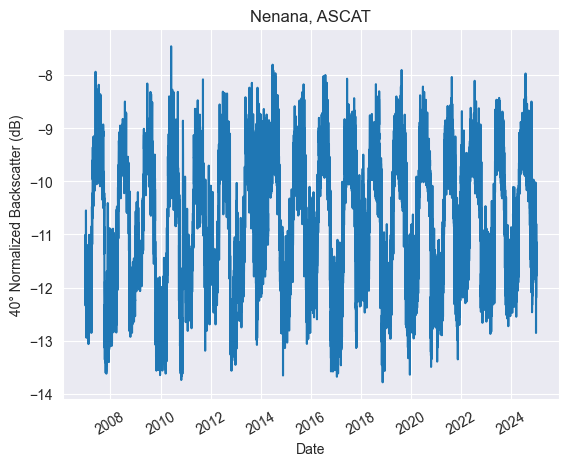

In [19]:
ASCAT_nenana_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NENANA_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_nenana_df,
               variable=ASCAT_short_var_name,
               station_name=c.NENANA_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

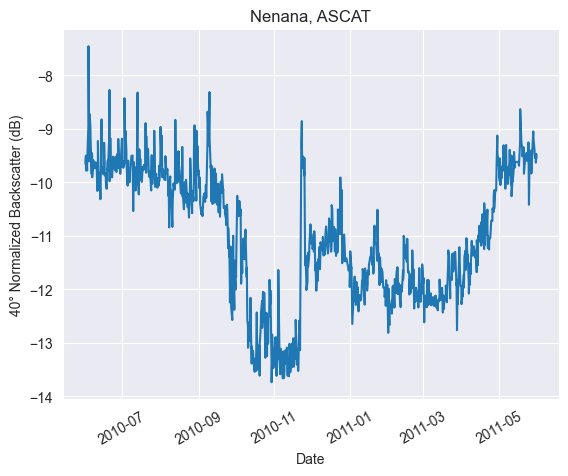

In [20]:
plot_one_year(ASCAT_nenana_df, ASCAT_short_var_name, c.NENANA_NAME, ASCAT, ASCAT_long_var_name)

In [21]:
# export to csv
ASCAT_nenana_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NENANA_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,2.152435
std,10.986415
min,-34.949005
25%,-5.701162
50%,-0.542542
75%,12.205104
max,29.949066


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-14.547028
2007-01-01 01:00:00+00:00,-14.726064
2007-01-01 02:00:00+00:00,-14.905101
2007-01-01 03:00:00+00:00,-15.084137
2007-01-01 04:00:00+00:00,-15.263173


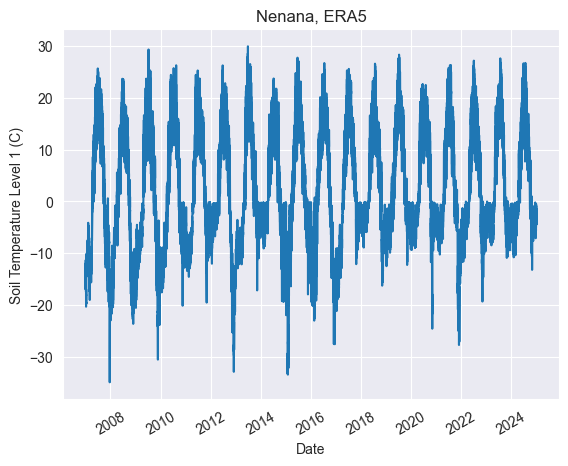

In [22]:
ERA5_nenana_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NENANA_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_nenana_df,
               variable=ERA5_short_var_name,
               station_name=c.NENANA_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [23]:
# export to csv
ERA5_nenana_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NENANA_NAME}_{ERA5}.csv')

### 2.5 L23

#### ASCAT

There are 874 nulls out of 14374 datapoints (0.06% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,13500.000000,13500.000000,13500.000000,13500.000000
mean,-11.809968,0.475037,0.504815,3.717037
std,1.496498,0.499395,0.499995,0.748413
min,-16.494514,0.000000,0.000000,3.000000
25%,-13.098708,0.000000,0.000000,3.000000
50%,-11.981903,0.000000,1.000000,4.000000
75%,-10.503685,1.000000,1.000000,4.000000
max,-7.121807,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 04:00:00+00:00,-12.918723,0,1,3
2007-01-02 16:00:00+00:00,-12.326420,1,0,3
2007-01-03 04:00:00+00:00,-14.347024,0,1,3
2007-01-03 15:00:00+00:00,-13.486931,1,0,3
2007-01-05 03:00:00+00:00,-13.790267,1,1,3


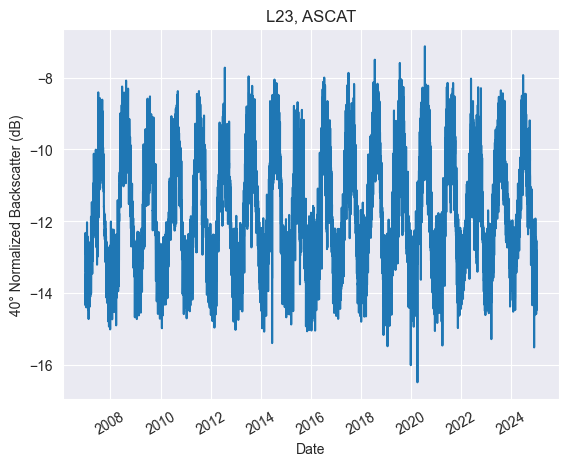

In [24]:
ASCAT_L23_df = data_cleaning(data_path=raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=c.L23_NAME,
                             system=ASCAT,
                             key_variable=ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_L23_df,
               variable=ASCAT_short_var_name,
               station_name=c.L23_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

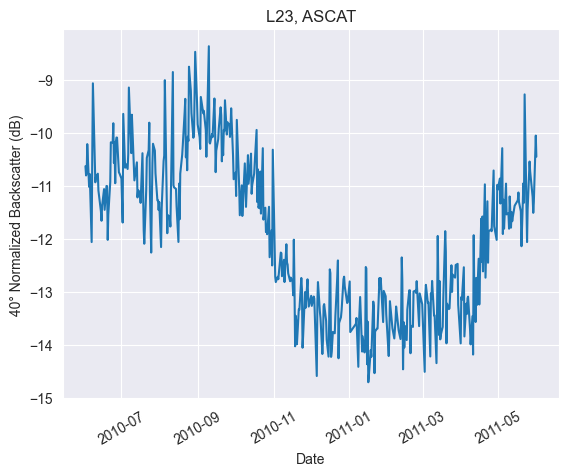

In [25]:
plot_one_year(ASCAT_L23_df, ASCAT_short_var_name, c.L23_NAME, ASCAT, ASCAT_long_var_name)

In [26]:
# export to csv
ASCAT_L23_df.to_csv(c.CLEANED_DATA_PATH / f'{c.L23_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,0.426881
std,6.085233
min,-14.649292
25%,-4.151253
50%,-1.241526
75%,5.490105
max,17.009247


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-4.203278
2007-01-01 01:00:00+00:00,-4.197418
2007-01-01 02:00:00+00:00,-4.191559
2007-01-01 03:00:00+00:00,-4.185700
2007-01-01 04:00:00+00:00,-4.179840


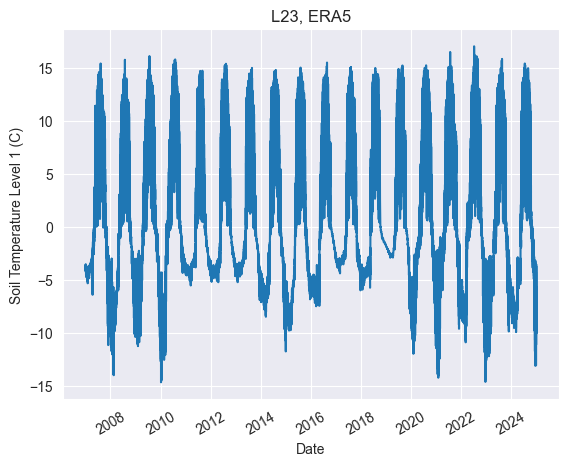

In [27]:
ERA5_L23_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.L23_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_L23_df,
               variable=ERA5_short_var_name,
               station_name=c.L23_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [28]:
# export to csv
ERA5_L23_df.to_csv(c.CLEANED_DATA_PATH / f'{c.L23_NAME}_{ERA5}.csv')

### 2.6 L38

#### ASCAT

There are 1594 nulls out of 14489 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,12895.000000,12895.000000,12895.000000,12895.000000
mean,-11.825687,0.503761,0.501745,3.712679
std,1.179467,0.500005,0.500016,0.747182
min,-15.653297,0.000000,0.000000,3.000000
25%,-12.854373,0.000000,0.000000,3.000000
50%,-12.000610,1.000000,1.000000,4.000000
75%,-10.820934,1.000000,1.000000,4.000000
max,-7.204072,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 04:00:00+00:00,-13.265300,0,1,3
2007-01-02 16:00:00+00:00,-13.208417,1,0,3
2007-01-03 04:00:00+00:00,-13.032414,0,1,3
2007-01-03 15:00:00+00:00,-13.790648,1,0,3
2007-01-05 03:00:00+00:00,-13.257554,1,1,3


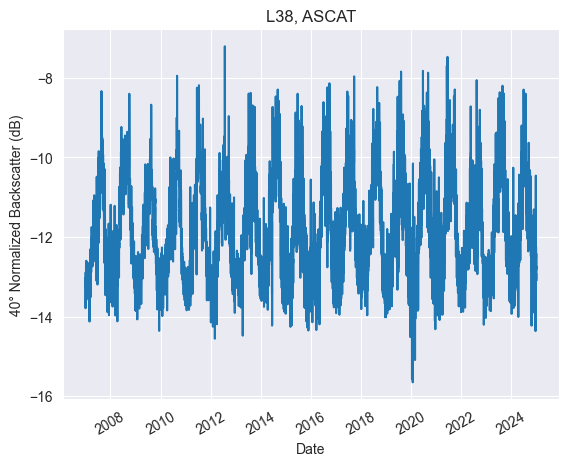

In [29]:
ASCAT_L38_df = data_cleaning(data_path=raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=c.L38_NAME,
                             system=ASCAT,
                             key_variable=ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_L38_df,
               variable=ASCAT_short_var_name,
               station_name=c.L38_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

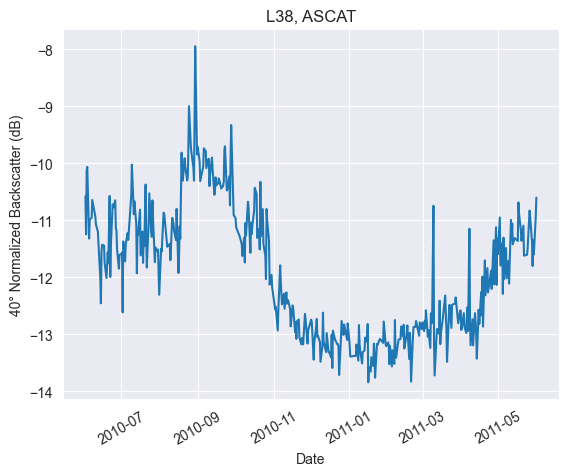

In [30]:
plot_one_year(ASCAT_L38_df, ASCAT_short_var_name, c.L38_NAME, ASCAT, ASCAT_long_var_name)

In [31]:
# export to csv
ASCAT_L38_df.to_csv(c.CLEANED_DATA_PATH / f'{c.L38_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,0.494238
std,6.428027
min,-18.951782
25%,-3.984228
50%,-0.778447
75%,5.804710
max,17.397919


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-4.507965
2007-01-01 01:00:00+00:00,-4.492991
2007-01-01 02:00:00+00:00,-4.478017
2007-01-01 03:00:00+00:00,-4.463043
2007-01-01 04:00:00+00:00,-4.448069


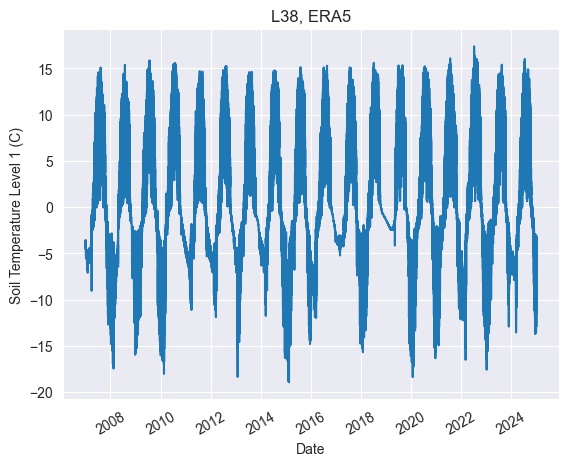

In [32]:
ERA5_L38_df = data_cleaning(data_path=raw_path,
                            ismn_sites_path=c.SITE_SURVEY_PATH,
                            station=c.L38_NAME,
                            system=ERA5,
                            key_variable=ERA5_short_var_name,
                            date_range=c.DATE_RANGE)
data_reporting(df=ERA5_L38_df,
               variable=ERA5_short_var_name,
               station_name=c.L38_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [33]:
# export to csv
ERA5_L38_df.to_csv(c.CLEANED_DATA_PATH / f'{c.L38_NAME}_{ERA5}.csv')

### 2.7 NST-07

#### ASCAT

There are 1049 nulls out of 15088 datapoints (0.07% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,14039.000000,14039.000000,14039.000000,14039.000000
mean,-13.714801,0.491203,0.498896,3.716789
std,2.183975,0.499940,0.500017,0.747316
min,-18.695620,0.000000,0.000000,3.000000
25%,-15.650910,0.000000,0.000000,3.000000
50%,-12.974967,0.000000,0.000000,4.000000
75%,-11.928774,1.000000,1.000000,4.000000
max,-9.411098,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 03:00:00+00:00,-18.340450,1,1,3
2007-01-02 14:00:00+00:00,-17.415730,0,0,3
2007-01-03 14:00:00+00:00,-16.352602,0,0,3
2007-01-04 04:00:00+00:00,-18.040010,0,1,3
2007-01-04 15:00:00+00:00,-17.644730,1,0,3


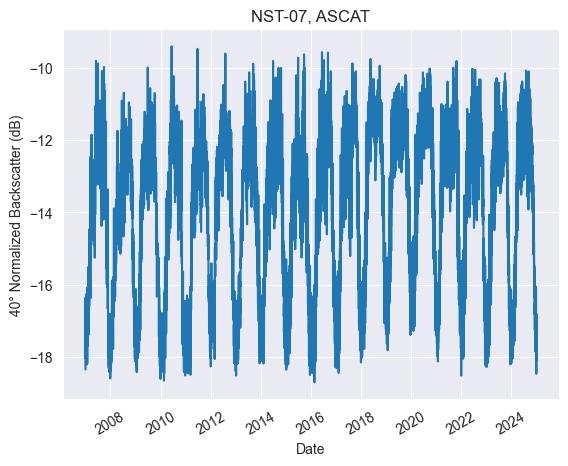

In [34]:
ASCAT_NST_07_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NST_07_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_NST_07_df,
               variable=ASCAT_short_var_name,
               station_name=c.NST_07_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

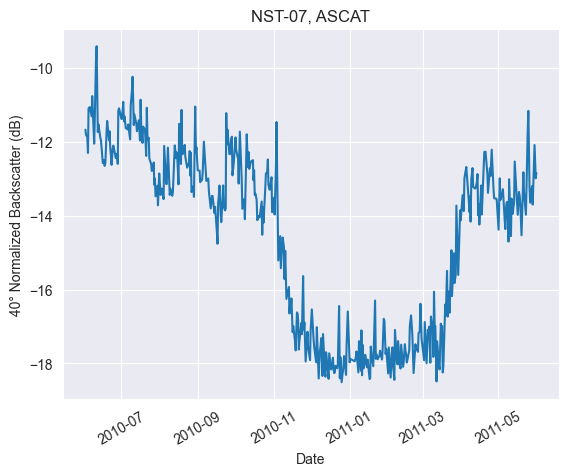

In [35]:
plot_one_year(ASCAT_NST_07_df, ASCAT_short_var_name, c.NST_07_NAME, ASCAT, ASCAT_long_var_name)

In [36]:
# export to csv
ASCAT_NST_07_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NST_07_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,3.110746
std,6.994822
min,-17.119934
25%,-2.210403
50%,2.232147
75%,9.081696
max,22.347748


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-11.910309
2007-01-01 01:00:00+00:00,-10.904775
2007-01-01 02:00:00+00:00,-9.899241
2007-01-01 03:00:00+00:00,-8.893707
2007-01-01 04:00:00+00:00,-7.888173


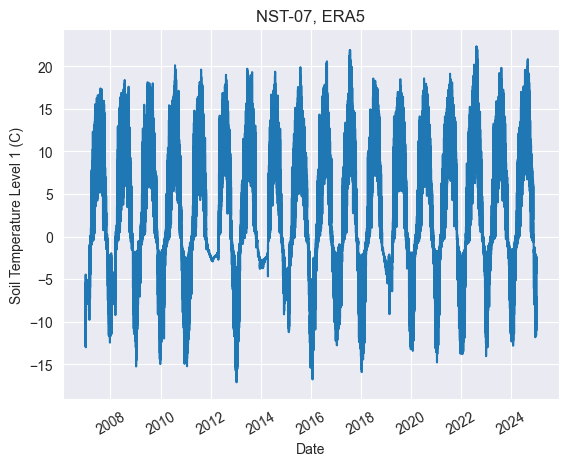

In [37]:
ERA5_NST_07_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NST_07_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_NST_07_df,
               variable=ERA5_short_var_name,
               station_name=c.NST_07_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [38]:
# export to csv
ERA5_NST_07_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NST_07_NAME}_{ERA5}.csv')

### 2.8 NST-09

#### ASCAT

There are 1423 nulls out of 14768 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,13345.000000,13345.000000,13345.000000,13345.000000
mean,-13.599529,0.489771,0.487523,3.710828
std,2.154390,0.499914,0.499863,0.746750
min,-19.681623,0.000000,0.000000,3.000000
25%,-15.369110,0.000000,0.000000,3.000000
50%,-12.889750,0.000000,0.000000,4.000000
75%,-11.836084,1.000000,1.000000,4.000000
max,-9.696083,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-02 03:00:00+00:00,-18.221373,1,1,3
2007-01-02 14:00:00+00:00,-17.126863,0,0,3
2007-01-03 14:00:00+00:00,-15.837445,0,0,3
2007-01-04 04:00:00+00:00,-17.808882,0,1,3
2007-01-04 15:00:00+00:00,-17.277155,1,0,3


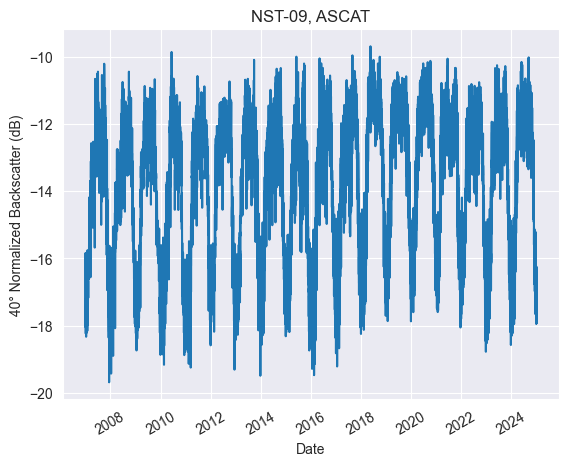

In [39]:
ASCAT_NST_09_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NST_09_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_NST_09_df,
               variable=ASCAT_short_var_name,
               station_name=c.NST_09_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

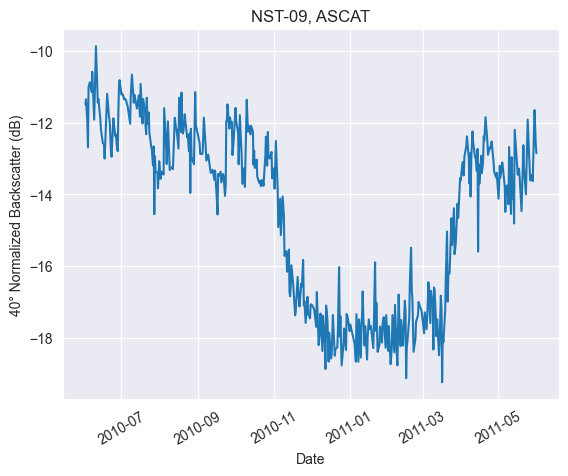

In [40]:
plot_one_year(ASCAT_NST_09_df, ASCAT_short_var_name, c.NST_09_NAME, ASCAT, ASCAT_long_var_name)

In [41]:
# export to csv
ASCAT_NST_09_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NST_09_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,3.110746
std,6.994822
min,-17.119934
25%,-2.210403
50%,2.232147
75%,9.081696
max,22.347748


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-11.910309
2007-01-01 01:00:00+00:00,-10.904775
2007-01-01 02:00:00+00:00,-9.899241
2007-01-01 03:00:00+00:00,-8.893707
2007-01-01 04:00:00+00:00,-7.888173


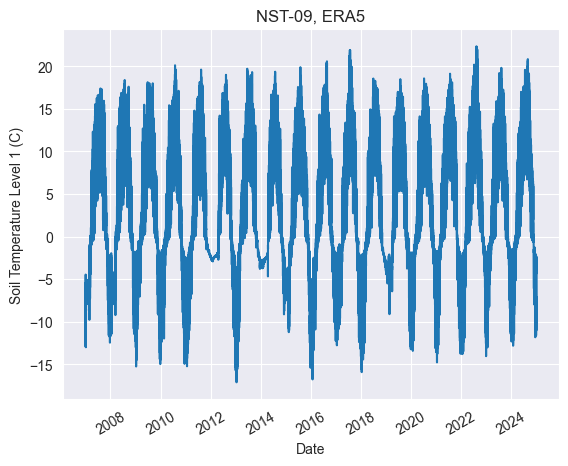

In [42]:
ERA5_NST_09_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NST_09_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_NST_09_df,
               variable=ERA5_short_var_name,
               station_name=c.NST_09_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [43]:
# export to csv
ERA5_NST_09_df.to_csv(c.CLEANED_DATA_PATH / f'{c.NST_09_NAME}_{ERA5}.csv')

### 2.9 SOD012

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,33578.000000,33578.000000,33578.000000,33578.000000
mean,-10.420756,0.430043,0.501132,3.717911
std,0.989236,0.495089,0.500006,0.748430
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.059022,0.000000,0.000000,3.000000
50%,-10.242341,0.000000,1.000000,4.000000
75%,-9.668062,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3
2007-01-02 19:00:00+00:00,-11.309603,1,0,3


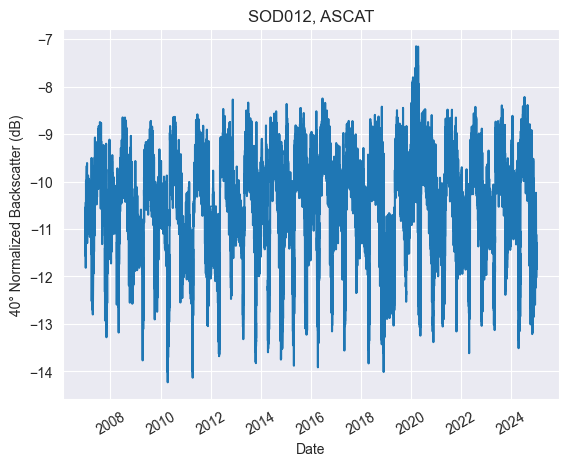

In [44]:
ASCAT_SOD012_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.SOD012_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_SOD012_df,
               variable=ASCAT_short_var_name,
               station_name=c.SOD012_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

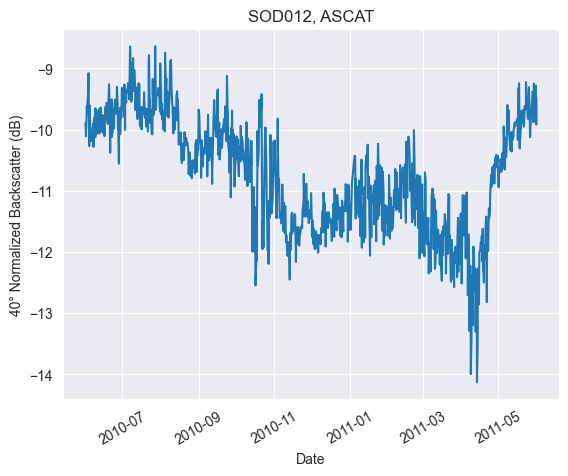

In [45]:
plot_one_year(ASCAT_SOD012_df, ASCAT_short_var_name, c.SOD012_NAME, ASCAT, ASCAT_long_var_name)

In [46]:
# export to csv
ASCAT_SOD012_df.to_csv(c.CLEANED_DATA_PATH / f'{c.SOD012_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,2.821513
std,7.145322
min,-15.353729
25%,-2.311691
50%,-0.422165
75%,8.808273
max,26.531800


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-1.742340
2007-01-01 01:00:00+00:00,-1.723785
2007-01-01 02:00:00+00:00,-1.705231
2007-01-01 03:00:00+00:00,-1.686676
2007-01-01 04:00:00+00:00,-1.668121


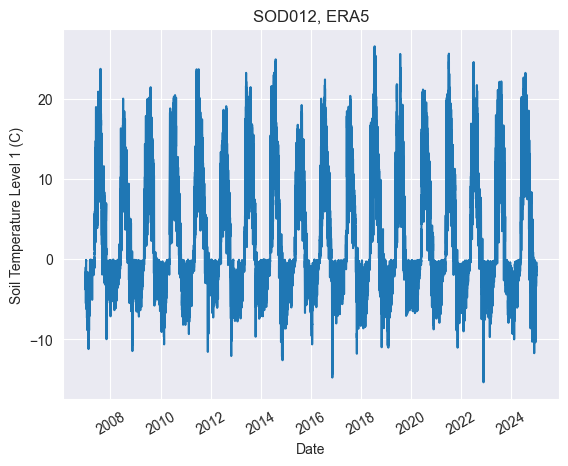

In [47]:
ERA5_SOD012_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.SOD012_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_SOD012_df,
               variable=ERA5_short_var_name,
               station_name=c.SOD012_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [48]:
# export to csv
ERA5_SOD012_df.to_csv(c.CLEANED_DATA_PATH / f'{c.SOD012_NAME}_{ERA5}.csv')

### 2.10 SOD103

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,33578.000000,33578.000000,33578.000000,33578.000000
mean,-10.420756,0.430043,0.501132,3.717911
std,0.989236,0.495089,0.500006,0.748430
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.059022,0.000000,0.000000,3.000000
50%,-10.242341,0.000000,1.000000,4.000000
75%,-9.668062,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
UTC_timestamp,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3
2007-01-02 19:00:00+00:00,-11.309603,1,0,3


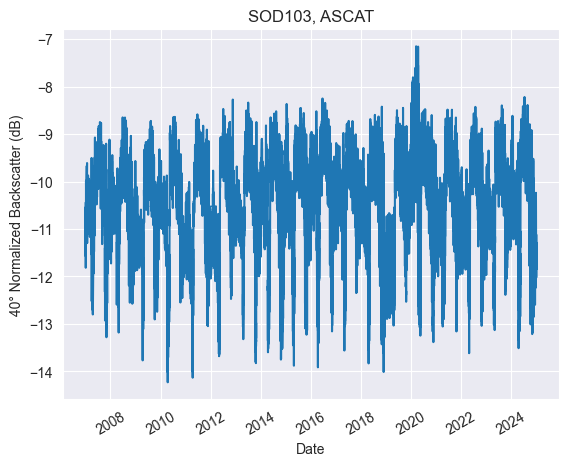

In [49]:
ASCAT_SOD103_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.SOD103_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_SOD103_df,
               variable=ASCAT_short_var_name,
               station_name=c.SOD103_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

Plot one year of ASCAT data to determine backscatter behavior for this location

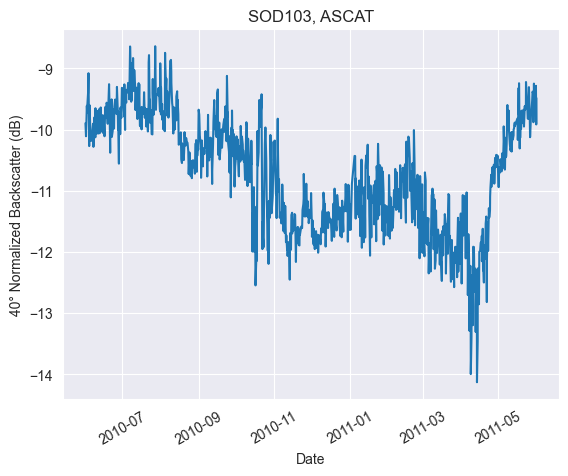

In [50]:
plot_one_year(ASCAT_SOD103_df, ASCAT_short_var_name, c.SOD103_NAME, ASCAT, ASCAT_long_var_name)

In [51]:
# export to csv
ASCAT_SOD103_df.to_csv(c.CLEANED_DATA_PATH / f'{c.SOD103_NAME}_{ASCAT}.csv')

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,stl1
count,157795.000000
mean,2.821513
std,7.145322
min,-15.353729
25%,-2.311691
50%,-0.422165
75%,8.808273
max,26.531800


Show head of df:


,stl1
UTC_timestamp,
2007-01-01 00:00:00+00:00,-1.742340
2007-01-01 01:00:00+00:00,-1.723785
2007-01-01 02:00:00+00:00,-1.705231
2007-01-01 03:00:00+00:00,-1.686676
2007-01-01 04:00:00+00:00,-1.668121


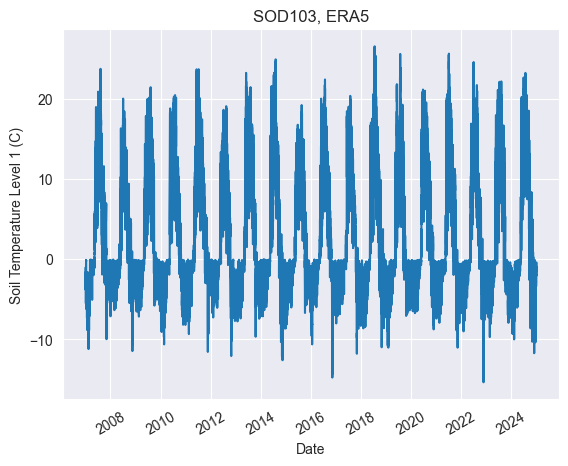

In [52]:
ERA5_SOD103_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.SOD103_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_SOD103_df,
               variable=ERA5_short_var_name,
               station_name=c.SOD103_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

In [53]:
# export to csv
ERA5_SOD103_df.to_csv(c.CLEANED_DATA_PATH / f'{c.SOD103_NAME}_{ERA5}.csv')